In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import ast  # <-- NUEVO: Para convertir los colores de texto a tuplas

In [15]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# Transformamos los colores (que vienen como texto) a tuplas de Python
hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
# Traducimos las formas al lenguaje de Matplotlib ('dot' -> 'o', 'star' -> '*')
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

# Renombramos columnas para que sean más intuitivas y fáciles de manejar
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()


pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})


# Convertimos a datetime para poder operar con tiempos
pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')

# Ordenamos obligatoriamente por paciente y fecha de ingreso para reconstruir la historia
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. DF AUXILIAR: INCONSISTENCIAS DE ID (Comentado)
# ==========================================
"""
# Detecta IDs que tienen más de una edad o más de un sexo registrado
inconsistencias = df_clean.groupby('paciente_id').agg(
    cant_edades=('Edad', lambda x: x.dropna().nunique()),
    cant_sexos=('Sexo', lambda x: x.dropna().nunique())
)
ids_problematicos = inconsistencias[(inconsistencias['cant_edades'] > 1) | (inconsistencias['cant_sexos'] > 1)].index

# DataFrame con los casos raros para revisar después
df_edades_inconsistentes = df_clean[df_clean['paciente_id'].isin(ids_problematicos)].copy()
"""


# # ==========================================
# # 3. CONSTRUCCIÓN DE TRASLADOS (El core del modelo)
# # ==========================================

pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos'
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0


# Definimos qué motivos consideramos como "traslado" real
motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']

# Filtramos: 
# 1. Que haya un destino
# 2. Que el motivo sea de traslado
# 3. (Opcional pero recomendado para tu grafo) Que origen y destino sean distintos

mask_traslados = (
    pacientes['hospital_destino'].notna() &
    pacientes['motivo_egreso'].isin(motivos_validos) &
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) 
)

df_potenciales = pacientes[mask_traslados].copy()
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})


# # ==========================================
# # 4. MANEJO DE TIEMPOS (> 30 días y Alertas)
# # ==========================================

# A. DF Auxiliar: Traslados que tardaron MÁS de 30 días (para consultar/auditar)
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()

# B. DF Principal de Traslados (<= 30 días)
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()

# Marcamos la alerta (Ejemplo: Si el traslado tardó más de 1 día, es una alerta)
# Podés cambiar el > 1 por el umbral que consideres "demora"
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 1
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)

# Renombramos para que encaje perfecto con el código del grafo que te pasé antes
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})


# # ==========================================
# # 5. DF DE TRAYECTORIAS (Reconstrucción completa)
# # ==========================================

# Agrupamos por paciente en la base de traslados válidos para ver su "viaje"
def armar_trayectoria(group):
    # Secuencia de hospitales: [Origen1, Destino1(que es Origen2), Destino2, ...]
    # Tomamos todos los orígenes y le sumamos el último destino para tener la ruta completa
    ruta = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    
    # Juntamos los días de alerta en un array/lista (solo guardamos los > 0 para que sea limpio)
    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales': " -> ".join(ruta),
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

# Solo armamos trayectoria de los que tuvieron al menos un traslado exitoso (<= 30 días)
df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()

# Mostramos cómo quedaron (opcional)
# print("Traslados listos para el grafo:", len(df_traslados))
# print("Traslados anómalos (>30 días):", len(df_mas_30_dias))
#display(df_trayectoria.head())

In [16]:
# paciente_testigo = 'WN04'
# display(pacientes[pacientes['paciente_id'] == paciente_testigo][['fecha_ingreso', 'hospital_origen', 'motivo_egreso', 'fecha_egreso', 'hospital_destino', 'dias_traslado', 'riesgo_clinico']])

# # Ver las 5 trayectorias con más traslados
# display(df_trayectoria.sort_values('cantidad_traslados', ascending=False).head(5))

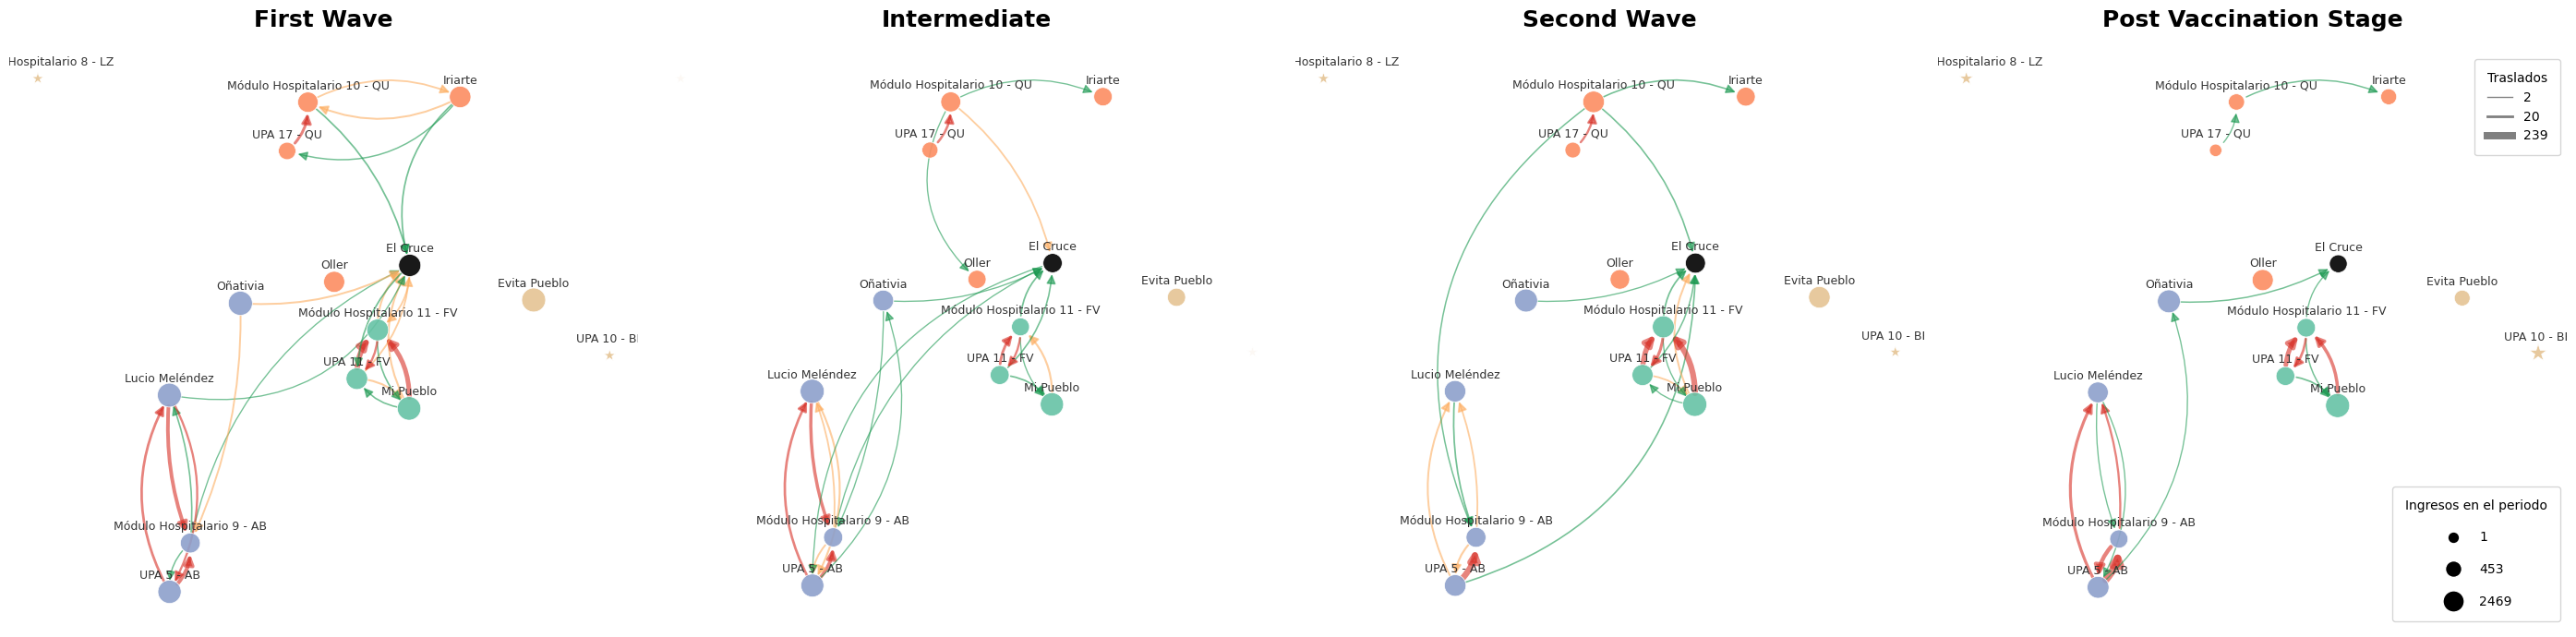

In [56]:
# ==========================================
# 3. PREPARACIÓN DE COORDENADAS
# ==========================================
df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
    # No renombramos 'color' y 'shape' porque ya tienen buenos nombres
})

# Separación de hospitales con mismas coordenadas
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []

for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        primeras = True
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if primeras:
                primeras = False
            else:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)

# Traductor de formas para NetworkX
mapa_formas = {
    'dot': 'o',   # Círculo
    'star': '*'   # Estrella
}

# ==========================================
# 4. CONFIGURACIÓN VISUAL
# ==========================================
periodos = [
    ('First Wave', '2020-06-01', '2020-10-31'),
    ('Intermediate', '2020-11-01', '2021-02-28'),
    ('Second Wave', '2021-03-01', '2021-07-31'),
    ('Post Vaccination Stage', '2021-08-01', '2022-12-31')
]

# Ya no usamos 'colores_localidad' porque el color viene del CSV

# ==========================================
# 5. DIBUJO DEL GRÁFICO (CORREGIDO Y NORMALIZADO)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(28, 7))
fig.patch.set_facecolor('white')

# Cálculos globales para referencias y leyendas
agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1

ingresos_globales = pacientes['hospital_origen'].value_counts()
MAX_INGRESOS_GLOBAL = ingresos_globales.max() if not ingresos_globales.empty else 1

# Constantes de diseño ajustadas para Raíz Cuadrada
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 8.0
MIN_TAMANO_NODO = 80     # Mínimo visible pero que no estorba
MAX_TAMANO_NODO = 350   # Máximo controlado para no tapar todo el mapa

hospitales_conocidos = set(df_coordenadas['hospital'])
valores_traslados_reales = []
valores_ingresos_reales = []

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes[idx]
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=20)
    
    # 1. FILTRADO DE INGRESOS (Para tamaño de nodos)
    mask_ingresos = (pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)
    ingresos_periodo_ser = pacientes[mask_ingresos]['hospital_origen'].value_counts()
    ingresos_por_hospital = ingresos_periodo_ser.to_dict()
    
    # 2. FILTRADO DE TRASLADOS (Para las flechas)
    mask_tras = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_periodo_traslados = df_traslados[mask_tras].copy()
    
    # Agrupamos DENTRO del bucle para que se actualice por periodo
    traslados_agrupados = df_periodo_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    
    # 3. ESCALA DINÁMICA POR PERIODO
    max_ing_periodo = ingresos_periodo_ser.max() if not ingresos_periodo_ser.empty else 1

    G = nx.DiGraph()
    
    # Añadir Nodos
    for _, row in df_coordenadas.iterrows():
        h = row['hospital']
        n_ing = ingresos_por_hospital.get(h, 0)
        
        # Guardamos para la leyenda
        if n_ing > 0: valores_ingresos_reales.append(n_ing)
        
        # ESCALA CON RAÍZ CUADRADA: Normaliza sin inflar de más a los chicos ni matar a los medianos
        escala_n = np.sqrt(n_ing) / np.sqrt(max_ing_periodo) if n_ing > 0 else 0
        tamano_nodo = MIN_TAMANO_NODO + (escala_n * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
        
        try:
            color_rgb = ast.literal_eval(str(row['color']))
        except:
            color_rgb = 'grey'
            
        forma_nodo = mapa_formas.get(row['shape'], 'o')
        
        # Si no tiene ingresos en este periodo, lo ponemos casi invisible
        alpha_val = 0.9 if n_ing > 0 else 0.1
        
        G.add_node(h, pos=(row['lon'], row['lat']), color=color_rgb, size=tamano_nodo, shape=forma_nodo, alpha=alpha_val)

    # Añadir Aristas
    for _, row_t in traslados_agrupados.iterrows():
        u, v, peso = row_t['hospital_ingreso'], row_t['hospital_destino'], row_t['peso']
        if u in hospitales_conocidos and v in hospitales_conocidos:
            G.add_edge(u, v, weight=peso)

    posiciones = nx.get_node_attributes(G, 'pos')
    
    # Dibujar Nodos agrupando por forma
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    for forma in formas_presentes:
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nx.draw_networkx_nodes(G, posiciones, nodelist=nodelist, ax=ax, 
                               node_shape=forma, 
                               node_color=[G.nodes[n]['color'] for n in nodelist], 
                               node_size=[G.nodes[n]['size'] for n in nodelist], 
                               alpha=[G.nodes[n]['alpha'] for n in nodelist],
                               edgecolors='white', linewidths=0.5)

    # Dibujar Aristas
    for u, v, data in G.edges(data=True):
        peso = data['weight']

        if peso <= 1: 
            continue
        valores_traslados_reales.append(peso)
        
        escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

        if peso > 10: color_flecha = '#d73027'
        elif peso > 5: color_flecha = '#fdae61'
        else: color_flecha = '#1a9850'
    
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 85 - 35) / 100.0
        if abs(rad_dinamico) < 0.12:
            rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                                width=grosor, edge_color=color_flecha, alpha=0.6,
                                arrowstyle='-|>', arrowsize=15,
                                connectionstyle=f"arc3,rad={rad_dinamico}")

    # Etiquetas
    labels = {k: k for k in G.nodes() if ingresos_por_hospital.get(k, 0) > 0 or G.out_degree(k) > 0}
    pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}

    nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=9,
                        font_color='#333333', font_family='sans-serif')

    ax.axis('off')

# ==========================================
# 6. LEYENDAS
# ==========================================
ax_leyenda = axes[-1]

# --- A. TRASLADOS ---
if valores_traslados_reales:
    min_t, med_t, max_t = min(valores_traslados_reales), int(np.mean(valores_traslados_reales)), max(valores_traslados_reales)
else:
    min_t, med_t, max_t = 3, 5, 10

def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

line_1 = mlines.Line2D([], [], color='grey', linewidth=calc_grosor(min_t), label=f'{min_t}')
line_2 = mlines.Line2D([], [], color='grey', linewidth=calc_grosor(med_t), label=f'{med_t}')
line_3 = mlines.Line2D([], [], color='grey', linewidth=calc_grosor(max_t), label=f'{max_t}')
legend1 = ax_leyenda.legend(handles=[line_1, line_2, line_3], title="Traslados", loc='upper right', frameon=True, borderpad=1)
ax_leyenda.add_artist(legend1)

# --- B. INGRESOS ---
if valores_ingresos_reales:
    min_i, med_i, max_i = min(valores_ingresos_reales), int(np.mean(valores_ingresos_reales)), max(valores_ingresos_reales)
else:
    min_i, med_i, max_i = 10, 50, 100

def calc_markersize(ingreso):
    # Usamos la misma lógica de Raíz Cuadrada para que la leyenda coincida con el mapa
    escala = np.sqrt(ingreso) / np.sqrt(MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
    area = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return np.sqrt(area)

node_1 = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='black', markersize=calc_markersize(min_i), label=f'{min_i}')
node_2 = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='black', markersize=calc_markersize(med_i), label=f'{med_i}')
node_3 = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='black', markersize=calc_markersize(max_i), label=f'{max_i}')
legend2 = ax_leyenda.legend(handles=[node_1, node_2, node_3], title="Ingresos en el periodo", loc='lower right', frameon=True, borderpad=1, labelspacing=1.5, handletextpad=1)

plt.tight_layout()
plt.show()

In [67]:
df = pacientes[pacientes['hospital_origen'] == 'UPA 10 - BE'] \
        .sort_values(by='fecha_egreso')

df

,hospital_id,hospital_origen,paciente_id,fecha_ingreso,estado_ingreso,tipo_ingreso,estado_ultimo,tipo_ultimo,sexo,edad,...,operacion,fecha_egreso,fecha_ultima_actualizacion,paso_criticas,paso_intermedias,paso_generales,hospital_destino,fecha_ingreso_destino,dias_traslado,eror_fechas
2,148,UPA 10 - BE,1,2020-06-07 12:11:28,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,NaN,...,egreso,2020-06-08 12:11:28,2020-07-21 14:34:52,no,si,no,NaN,NaT,NaN,NaN
6627,148,UPA 10 - BE,FR52,NaT,sospechosos,intermedias,sospechosos,intermedias,masculino,NaN,...,egreso,2020-06-12 12:11:28,2020-07-21 14:34:52,no,si,no,NaN,NaT,NaN,NaN
29181,148,UPA 10 - BE,ZO35,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,...,egreso,2020-06-13 12:11:28,2020-07-21 14:34:52,no,si,no,NaN,NaT,NaN,NaN
26939,148,UPA 10 - BE,XN78,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,...,egreso,2020-06-13 12:11:28,2020-07-21 14:34:52,no,si,no,NaN,NaT,NaN,NaN
4479,148,UPA 10 - BE,DV18,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,...,egreso,2021-08-06 12:11:29,2021-08-06 14:58:38,no,si,no,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29651,148,UPA 10 - BE,ZZ25,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,...,egreso,NaT,2020-10-07 20:55:05,no,si,no,NaN,NaT,NaN,NaN
29662,148,UPA 10 - BE,ZZ43,NaT,ocupadas_otros,intermedias,ocupadas_otros,intermedias,NaN,NaN,...,egreso,NaT,2021-11-16 12:47:07,no,si,no,NaN,NaT,NaN,NaN
29669,148,UPA 10 - BE,ZZ56,NaT,ocupadas_otros,intermedias,ocupadas_otros,intermedias,NaN,NaN,...,egreso,NaT,2020-07-21 14:34:52,no,si,no,NaN,NaT,NaN,NaN
29677,148,UPA 10 - BE,ZZ71,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,...,egreso,NaT,2020-08-07 19:33:59,no,si,no,NaN,NaT,NaN,NaN


In [62]:
## prueba para ver que tal evita pueblo
inicio = '2020-11-01'
fin = '2021-02-28'


df_periodo = pacientes[
    (pacientes['fecha_egreso'] >= inicio) &
    (pacientes['fecha_egreso'] <= fin)
].copy()

df_ingresos_upa10 = df_periodo[
    (df_periodo['hospital_origen'] == 'UPA 10 - BE')
].copy()

# df_evita_a_modulo = df_periodo[
#     (df_periodo['hospital_ingreso'] == 'Evita Pueblo') &
#     (df_periodo['hospital_destino'] == 'Módulo Hospitalario 10 - QU')
# ].copy()

cantidad = len(df_ingresos_upa10)
print("Cantidad de traslados:", cantidad)

df_ingresos_upa10


Cantidad de traslados: 0


,hospital_id,hospital_origen,paciente_id,fecha_ingreso,estado_ingreso,tipo_ingreso,estado_ultimo,tipo_ultimo,sexo,edad,...,operacion,fecha_egreso,fecha_ultima_actualizacion,paso_criticas,paso_intermedias,paso_generales,hospital_destino,fecha_ingreso_destino,dias_traslado,eror_fechas


In [23]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

# Limpieza profunda de strings
pacientes['hospital_origen'] = pacientes['hospital_origen'].astype(str).str.strip()
hospitales['Nombre Hospital'] = hospitales['Nombre Hospital'].astype(str).str.strip()

# Verificamos si hay nombres que "parecen" iguales pero no lo son
nombres_pacientes = set(pacientes['hospital_origen'].unique())
nombres_coordenadas = set(hospitales['Nombre Hospital'].unique())

print(f"Hospitales en Excel Pacientes: {len(nombres_pacientes)}")
print(f"Hospitales en CSV Coordenadas: {len(nombres_coordenadas)}")

# ¿Qué hospitales están en pacientes pero NO en el archivo de coordenadas?
# (Si no están en coordenadas, el gráfico los ignora y perdés esos ingresos)
huerfanos = nombres_pacientes - nombres_coordenadas
if huerfanos:
    print(f"⚠️ Alerta: Estos hospitales no tienen coordenadas: {huerfanos}")

def check_ingresos_reales(df, inicio, fin):
    mask = (df['fecha_ingreso'] >= inicio) & (df['fecha_ingreso'] <= fin)
    conteo = df[mask]['hospital_origen'].value_counts()
    return conteo

# Probemos con el primer periodo
inicio_w1, fin_w1 = '2020-06-01', '2020-10-31'
resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

print(f"--- Ingresos Totales (Wave 1) ---")
print(resumen_w1.head(10)) 
print(f"Total general periodo: {resumen_w1.sum()}")

# Probemos con el 2do periodo
inicio_w1, fin_w1 = '2020-11-01', '2021-02-28'
resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

print(f"--- Ingresos Totales (Wave 1) ---")
print(resumen_w1.head(10)) 
print(f"Total general periodo: {resumen_w1.sum()}")


# Probemos con el 3er periodo
inicio_w1, fin_w1 = '2021-03-01', '2021-07-31'
resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

print(f"--- Ingresos Totales (Wave 1) ---")
print(resumen_w1.head(10)) 
print(f"Total general periodo: {resumen_w1.sum()}")


# Probemos con el 4to periodo
inicio_w1, fin_w1 = '2021-08-01', '2022-12-31'
resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

print(f"--- Ingresos Totales (Wave 1) ---")
print(resumen_w1.head(10)) 
print(f"Total general periodo: {resumen_w1.sum()}")

Hospitales en Excel Pacientes: 15
Hospitales en CSV Coordenadas: 15
--- Ingresos Totales (Wave 1) ---
hospital_origen
Oñativia                       710
Evita Pueblo                   693
Lucio Meléndez                 684
Mi Pueblo                      633
UPA 5 - AB                     597
El Cruce                       457
Módulo Hospitalario 11 - FV    414
UPA 11 - FV                    396
Iriarte                        389
Oller                          342
Name: count, dtype: int64
Total general periodo: 5944
--- Ingresos Totales (Wave 1) ---
hospital_origen
Lucio Meléndez                 561
Mi Pueblo                      470
UPA 5 - AB                     437
Oñativia                       249
Módulo Hospitalario 10 - QU    198
El Cruce                       154
Módulo Hospitalario 9 - AB     151
UPA 11 - FV                    143
Iriarte                        118
Evita Pueblo                   108
Name: count, dtype: int64
Total general periodo: 2839
--- Ingresos Totales (Wa

In [24]:
# Vamos a ver si hay pacientes con múltiples ingresos el mismo día o muy cerca
duplicados_potenciales = pacientes.groupby(['paciente_id', 'fecha_ingreso']).size()
duplicados_potenciales = duplicados_potenciales[duplicados_potenciales > 1]

if not duplicados_potenciales.empty:
    print(f"Cuidado: Hay {len(duplicados_potenciales)} casos de IDs con múltiples registros en la misma fecha.")
    # Esto podría estar inflando tus números de ingresos.

Cuidado: Hay 31 casos de IDs con múltiples registros en la misma fecha.


In [25]:
hosp_ruido = 'Oller' # <--- CAMBIAR POR EL QUE TE DE MAL
periodo_inicio = '2020-06-01'
periodo_fin = '2020-10-31'

# 1. Filtramos pacientes en ese hospital y fecha
test_df = pacientes[
    (pacientes['hospital_origen'] == hosp_ruido) & 
    (pacientes['fecha_ingreso'] >= periodo_inicio) & 
    (pacientes['fecha_ingreso'] <= periodo_fin)
]

print(f"Auditoría para {hosp_ruido}:")
print(f"Registros encontrados: {len(test_df)}")
print(f"Pacientes únicos: {test_df['paciente_id'].nunique()}")

# Si Registros > Pacientes únicos, tenés re-ingresos o duplicados que te inflan el número.

Auditoría para Oller:
Registros encontrados: 342
Pacientes únicos: 342
